## Waze's Predict User Churn Project

**Machine Learning Models**

$Task:$ To predict whether or not a Waze user is retained or churned.

*Task 1: Imports and data loading*

In [1]:
# Import packages for data manipulation
import os
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance
from xgboost import plot_importance

# This module lets us save our models once we fit them.
import pickle

In [2]:
# Import dataset
get_cwd = os.getcwd()
df0 = pd.read_csv(get_cwd + '/waze_dataset.csv')

In [3]:
# Inspect the first five rows
df0.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


*2a. Feature Engineering*

In [4]:
# Copy the df0 dataframe
df = df0.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [6]:
# 1. km_per_driving_day

# Create `km_per_driving_day` feature
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

In [7]:
# Get descriptive stats
df['km_per_driving_day'].describe()

c:\Users\222817\anaconda3\envs\minimal_ds\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

Notice that some values are infinite. This is the result of there being values of zero in the `driving_days` column.

In [8]:
# Convert infinite values to zero
df.loc[df['km_per_driving_day'] == np.inf, 'km_per_driving_day'] = 0

In [9]:
# Confirm that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

In [10]:
# 2. percent_sessions_in_last_month
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

# Get descriptive stats
df['percent_sessions_in_last_month'].describe()

count    14999.000000
mean         0.449255
std          0.286919
min          0.000000
25%          0.196221
50%          0.423097
75%          0.687216
max          1.530637
Name: percent_sessions_in_last_month, dtype: float64

In [11]:
# 3. professional_driver
# 1 for users who had 60 or more drives and drove on 15+ days in the last month.
df['professional_driver'] = np.where((df['drives'] >= 60) & (df['driving_days'] >= 15), 1, 0)

In [12]:
# 4. total_sessionss_per_day
df['total_sessions_per_day'] = df['total_sessions'] / df['n_days_after_onboarding']

In [13]:
# Get descriptive stats
df['total_sessions_per_day'].describe()

count    14999.000000
mean         0.338698
std          1.314333
min          0.000298
25%          0.051037
50%          0.100775
75%          0.216269
max         39.763874
Name: total_sessions_per_day, dtype: float64

In [14]:
# 5. km_per_hour
df['km_per_hour'] = df['driven_km_drives'] / (df['duration_minutes_drives'] / 60)
df['km_per_hour'].describe()

count    14999.000000
mean       190.394608
std        334.674026
min         72.013095
25%         90.706222
50%        122.382022
75%        193.130119
max      23642.920871
Name: km_per_hour, dtype: float64

In [15]:
# 6. km_per_drive
df['km_per_drive'] = df['driven_km_drives'] / df['drives']
df['km_per_drive'].describe()

c:\Users\222817\anaconda3\envs\minimal_ds\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      1.008775e+00
25%      3.323065e+01
50%      7.488006e+01
75%      1.854667e+02
max               inf
Name: km_per_drive, dtype: float64

In [16]:
# Convert infinite values to zero
df.loc[df['km_per_drive'] == np.inf, 'km_per_drive'] = 0

# Confirm that it worked
df['km_per_drive'].describe()

count    14999.000000
mean       232.817946
std        620.622351
min          0.000000
25%         32.424301
50%         72.854343
75%        179.347527
max      15777.426560
Name: km_per_drive, dtype: float64

In [17]:
# 7. percent_of_sessions_to_favorite
df['percent_of_sessions_to_favorite'] = (df['total_navigations_fav1'] + df['total_navigations_fav2']) / df['total_sessions']

# Get descriptive stats
df['percent_of_sessions_to_favorite'].describe()

count    14999.000000
mean         1.665439
std          8.865666
min          0.000000
25%          0.203471
50%          0.649818
75%          1.638526
max        777.563629
Name: percent_of_sessions_to_favorite, dtype: float64

*3. Drop the missing values*

In [18]:
# Drop rows with missing values
df.dropna(subset=['label'], inplace = True)

In [19]:
df.shape

(14299, 20)

*4. Outliers*

We know from previous EDA that many of these columns have outliers. However, tree-based models are resilient to outliers. So there is no need to make any imputations.

*5. Variable encoding*

Dummying Features:
Create a new, binary column called `device2` that encodes user devices as follows:

* `Android` -> `0`
* `iPhone` -> `1`

In [20]:
# Create new `device2` variable
df['device2'] = np.where(df['device'] == 'Android', 0, 1)
df[['device', 'device2']].tail()

,device,device2
14994,iPhone,1
14995,Android,0
14996,iPhone,1
14997,iPhone,1
14998,iPhone,1


Target encoding: Change the data type of the `label` column to be binary. This change is needed to train the models.

Assign a `0` for all `retained` users.

Assign a `1` for all `churned` users.

In [21]:
# Create binary `label2` column
df['label2'] = np.where(df['label'] == 'retained', 0, 1)
df[['label', 'label2']].tail()

,label,label2
14994,retained,0
14995,retained,0
14996,retained,0
14997,churned,1
14998,retained,0


*6. Feature Selection*

Tree-based models can handle multicollinearity, so the only feature that can be cut is `ID`, since it doesn't contain any information relevant to churn.


In [22]:
# Drop `ID` column
df.drop('ID', inplace = True, axis=1)

*7. Evaluation Metrics*

In [23]:
# Get class balance of 'label' col
df['label'].value_counts(normalize = True) * 100

label
retained    82.264494
churned     17.735506
Name: proportion, dtype: float64

Approximately 18% of the users in this dataset churned. This is an unbalanced dataset, but not extremely so. It can be modeled without any class rebalancing.

It was already determined that the risks involved in making a false positive prediction are minimal. No one stands to get hurt, lose money, or suffer any other significant consequence if they are predicted to churn. Therefore, select the model based on the recall score.

*8. Modelling workflow and model selection*

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

*9. Split the data*

In [24]:
# 1. Isolate X variables
X = df.drop(columns = ['label', 'label2', 'device'])

# 2. Isolate y variable
y = df['label2']

# 3. Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = 42)

# 4. Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr, random_state = 42, test_size=0.25)


In [25]:
# Verify the number of samples in the partitioned data.
for x in [X_train, X_val, X_test]:
    print(len(x))

8579
2860
2860


*10. Modelling*
1. RandomForest

In [26]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier()

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth' : [None],
             'max_features' : [1.0],
             'max_samples' : [1.0],
             'min_samples_leaf' : [2],
             'min_samples_split' : [2],
             'n_estimators' : [300]}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring = scoring, cv = 4, refit='recall')

In [27]:
# Fit the model
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None], 'max_features': [1.0],
                         'max_samples': [1.0], 'min_samples_leaf': [2],
                         'min_samples_split': [2], 'n_estimators': [300]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [28]:
# Examine best score
rf_cv.best_score_

np.float64(0.13204171846940185)

In [29]:
# Examine best hyperparameter combo
rf_cv.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [30]:
# make_results() function to output all the scores of your model.

def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

  # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision' : 'mean_test_precision',
                 'recall' : 'mean_test_recall',
                 'f1' : 'mean_test_f1',
                 'accuracy' : 'mean_test_accuracy'}

  # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

  # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

  # Extract Accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

  # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'accuracy': [accuracy],
                          'recall': [recall],
                          'f1': [f1]})
    
    return table
    

In [31]:
results = make_results("RF CV", rf_cv, 'recall')
results

,model,precision,accuracy,recall,f1
0,RF CV,0.476384,0.820258,0.132042,0.206692


Asside from the accuracy, the scores aren't that good. However, recall that when you built the logistic regression model, the recall was \~0.09, which means that this model has 33% better recall and about the same accuracy, and it was trained on less data.

2. XGBoost Model

In [32]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [6, 12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300]}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring = scoring, cv = 4, refit='recall')

In [33]:
# Fit the model
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [6, 12],
                         'min_child_weight': [3, 5], 'n_estimators': [300]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [34]:
# Examine best score
xgb_cv.best_score_

np.float64(0.1708264263019754)

In [35]:
# Examine best parameters
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 5,
 'n_estimators': 300}

In [36]:
# Call 'make_results()' on the GridSearch object
xgb_results = make_results("XGB CV", xgb_cv, 'recall')
results = pd.concat([results, xgb_results], axis = 0)
results

,model,precision,accuracy,recall,f1
0,RF CV,0.476384,0.820258,0.132042,0.206692
0,XGB CV,0.425932,0.811866,0.170826,0.243736


This model fit the data even better than the random forest model. The recall score is nearly double the recall score from the logistic regression model from the previous course, and it's almost 50% better than the random forest model's recall score, while maintaining a similar accuracy and precision score.

*11. Model Selection*

Use the best random forest model and the best XGBoost model to predict on the validation data. Whichever performs better will be selected as the champion model.

1. RandomForest

In [37]:
# Use random forest model to predict on validation data
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

In [38]:
# get_test_scores() function to generate a table of scores from the predictions on the vaidation data.
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [39]:
# Get validation scores for RF model
rf_val_scores = get_test_scores("RF VAL", rf_val_preds, y_val)

# Append to the results table
results = pd.concat([results, rf_val_scores], axis = 0)
results

,model,precision,accuracy,recall,f1
0,RF CV,0.476384,0.820258,0.132042,0.206692
0,XGB CV,0.425932,0.811866,0.170826,0.243736
0,RF VAL,0.475177,0.820280,0.132150,0.206790


Notice that the scores went down from the training scores across all metrics, but only by very little. This means that the model did not overfit the training data.

2. XGBoost

In [40]:
# Use XGBoost model to predict on validation data
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# Get validation scores for XGBoost model
xgb_val_scores = get_test_scores("XGB VAL", xgb_val_preds, y_val)

# Append to the results table
results = pd.concat([results, xgb_val_scores], axis = 0)
results

,model,precision,accuracy,recall,f1
0,RF CV,0.476384,0.820258,0.132042,0.206692
0,XGB CV,0.425932,0.811866,0.170826,0.243736
0,RF VAL,0.475177,0.820280,0.132150,0.206790
0,XGB VAL,0.422680,0.812238,0.161736,0.233951


Just like with the random forest model, the XGBoost model's validation scores were lower, but only very slightly. It is still the clear champion.

*12. Use the best model to predict on test data*

In [41]:
# Use XGBoost model to predict on test data
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test)

# Get test scores for XGBoost model
xgb_test_scores = get_test_scores("XGB Test", xgb_test_preds, y_test)

# Append to the results table
results = pd.concat([results, xgb_test_scores], axis = 0)
results

,model,precision,accuracy,recall,f1
0,RF CV,0.476384,0.820258,0.132042,0.206692
0,XGB CV,0.425932,0.811866,0.170826,0.243736
0,RF VAL,0.475177,0.820280,0.132150,0.206790
0,XGB VAL,0.422680,0.812238,0.161736,0.233951
0,XGB Test,0.423963,0.811189,0.181460,0.254144


The recall was exactly the same as it was on the validation data, but the precision declined notably, which caused all of the other scores to drop slightly. Nonetheless, this is stil within the acceptable range for performance discrepancy between validation and test scores.

*13. Confusion Matrix*

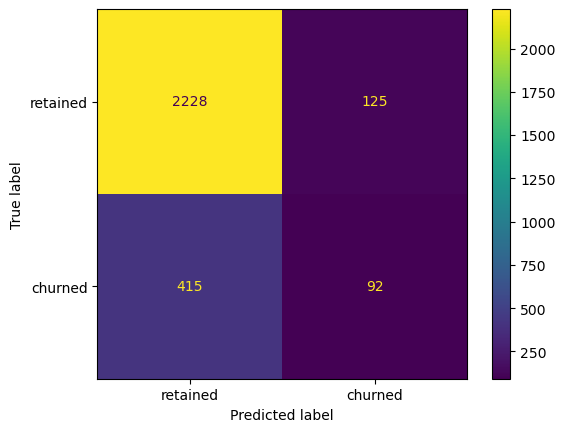

In [42]:
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, xgb_test_preds, labels = xgb_cv.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['retained', 'churned'])

disp.plot()

The model predicted three times as many false negatives than it did false positives, and it correctly identified only 16.6% of the users who actually churned.

*14. Feature importance*

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

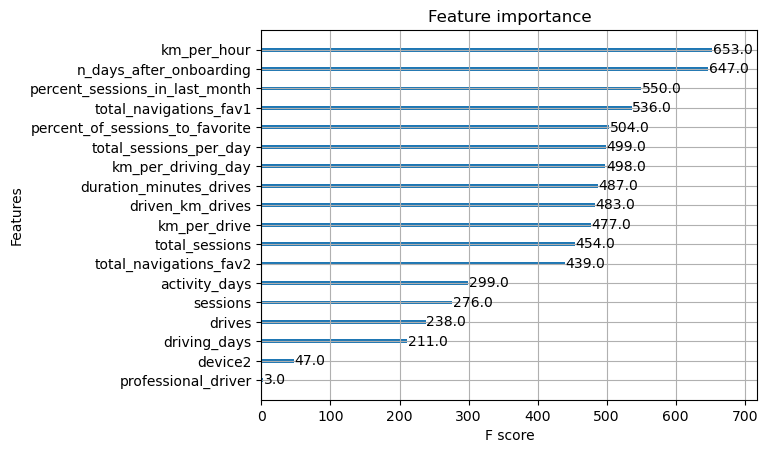

In [43]:
# Inspect the most important features
plot_importance(xgb_cv.best_estimator_)

*15. Conclusion*

The XGBoost model made more use of many of the features than did the logistic regression model. 

Notice that engineered features accounted for six of the top 10 features (and three of the top five). Feature engineering is often one of the best and easiest ways to boost model performance.

New features could be engineered to try to generate better predictive signal, as they often do if you have domain knowledge. In the case of this model, the engineered features made up over half of the top 10 most-predictive features used by the model. It could also be helpful to reconstruct the model with different combinations of predictor variables to reduce noise from unpredictive features.

It would be helpful to have drive-level information for each user (such as drive times, geographic locations, etc.). It would probably also be helpful to have more granular data to know how users interact with the app.